Transformer Models (BERT / DistilBERT / RoBERTa)
**CDS6344 Social Media Computing — Amazon Reviews Sentiment Analysis**

This notebook implements:
- Fine-tuned BERT for sentiment classification
- Fine-tuned DistilBERT (lighter, faster BERT)
- Fine-tuned RoBERTa
- Full evaluation & comparison table

> **Note:** Run on Google Colab with GPU runtime (Runtime → Change runtime type → T4 GPU)

## 1. Setup

In [ ]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 5.5.1 requires ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.3.0 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 2. Load Dataset & Label

In [ ]:
df = pd.read_csv('Amazon_Reviews.csv', on_bad_lines='skip', engine='python')

def rating_to_sentiment(rating_str):
    if pd.isna(rating_str):
        return None
    match = re.search(r'(\d)', str(rating_str))
    if not match:
        return None
    stars = int(match.group(1))
    if stars <= 2:   return 'Negative'
    elif stars == 3: return 'Neutral'
    else:            return 'Positive'

df['Sentiment'] = df['Rating'].apply(rating_to_sentiment)
df = df.dropna(subset=['Sentiment', 'Review Text'])
df = df[df['Review Text'].str.strip() != '']

# Light cleaning — transformers handle their own tokenization
def light_clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII
    return text.strip()

df['Clean_Text'] = df['Review Text'].apply(light_clean)

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Sentiment'])
NUM_CLASSES  = len(le.classes_)
CLASS_NAMES  = list(le.classes_)
print('Classes:', CLASS_NAMES)
print('Dataset size:', len(df))

# Subsample for speed — comment out if you have full GPU time
# df = df.sample(n=5000, random_state=42).reset_index(drop=True)

X_train, X_temp, y_train, y_temp = train_test_split(
    df['Clean_Text'], df['Label'],
    test_size=0.2, random_state=42, stratify=df['Label']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print(f'Train {len(X_train)} | Val {len(X_val)} | Test {len(X_test)}')

Classes: ['Negative', 'Neutral', 'Positive']
Dataset size: 21055
Train 16844 | Val 2105 | Test 2106


## 3. Dataset Class for Transformers

In [ ]:
class ReviewDatasetTransformer(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

## 4. Generic Fine-Tuning Function

In [ ]:
def fine_tune_transformer(model_name, X_train, y_train, X_val, y_val,
                           X_test, y_test, epochs=3, batch_size=16, lr=2e-5):
    """
    Fine-tune any HuggingFace sequence classification model.
    Works for BERT, DistilBERT, RoBERTa with the same code.
    """
    print(f'\n{"="*60}')
    print(f'Fine-tuning: {model_name}')
    print(f'{"="*60}')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_CLASSES
    ).to(device)

    MAX_LEN = 128
    train_ds = ReviewDatasetTransformer(X_train, y_train, tokenizer, MAX_LEN)
    val_ds   = ReviewDatasetTransformer(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds  = ReviewDatasetTransformer(X_test,  y_test,  tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    short_name    = model_name.split('/')[-1]

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for batch in train_loader:
            ids   = batch['input_ids'].to(device)
            masks = batch['attention_mask'].to(device)
            lbls  = batch['label'].to(device)
            optimizer.zero_grad()
            out  = model(input_ids=ids, attention_mask=masks, labels=lbls)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()

        # Validate
        model.eval()
        val_loss, correct, total_s = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                ids   = batch['input_ids'].to(device)
                masks = batch['attention_mask'].to(device)
                lbls  = batch['label'].to(device)
                out   = model(input_ids=ids, attention_mask=masks, labels=lbls)
                val_loss += out.loss.item()
                preds     = out.logits.argmax(dim=1)
                correct  += (preds == lbls).sum().item()
                total_s  += lbls.size(0)

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        val_acc   = correct    / total_s
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(val_acc)
        print(f'  Epoch {epoch+1}/{epochs} | Train Loss {avg_train:.4f} | Val Loss {avg_val:.4f} | Val Acc {val_acc:.4f}')

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), f'best_{short_name}.pt')

    # Evaluate on test set
    model.load_state_dict(torch.load(f'best_{short_name}.pt', map_location=device))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            ids   = batch['input_ids'].to(device)
            masks = batch['attention_mask'].to(device)
            lbls  = batch['label']
            out   = model(input_ids=ids, attention_mask=masks)
            preds = out.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds)

    print(f'\nTest Results — {short_name}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    # Confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{short_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{short_name}_confusion_matrix.png', dpi=150)
    plt.show()

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train', color='royalblue')
    axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
    axes[0].set_title(f'{short_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(history['val_acc'], color='seagreen', label='Val Acc')
    axes[1].set_title(f'{short_name} — Val Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{short_name}_training_curves.png', dpi=150)
    plt.show()

    return {
        'Model': short_name, 'Accuracy': acc,
        'Precision': prec, 'Recall': rec, 'F1-Score': f1
    }, history

## 5. Fine-Tune BERT


Fine-tuning: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\Abirami Muthiah\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abirami Muthiah\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3 | Train Loss 0.3598 | Val Loss 0.2303 | Val Acc 0.9264
  Epoch 2/3 | Train Loss 0.2048 | Val Loss 0.2468 | Val Acc 0.9268
  Epoch 3/3 | Train Loss 0.1430 | Val Loss 0.2860 | Val Acc 0.9197


C:\Users\Abirami Muthiah\AppData\Local\Temp\ipykernel_2660\3980990768.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_{short_nam


Test Results — bert-base-uncased
  Accuracy : 0.9122
  Precision: 0.9180
  Recall   : 0.9122
  F1-Score : 0.8938
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95      1435
     Neutral       1.00      0.01      0.02        89
    Positive       0.84      0.94      0.89       582

    accuracy                           0.91      2106
   macro avg       0.93      0.64      0.62      2106
weighted avg       0.92      0.91      0.89      2106



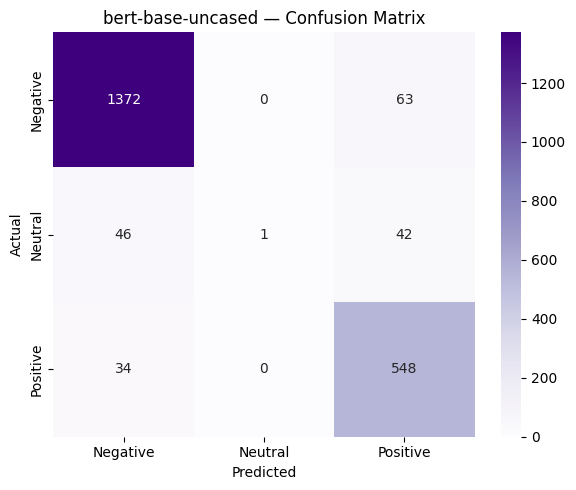

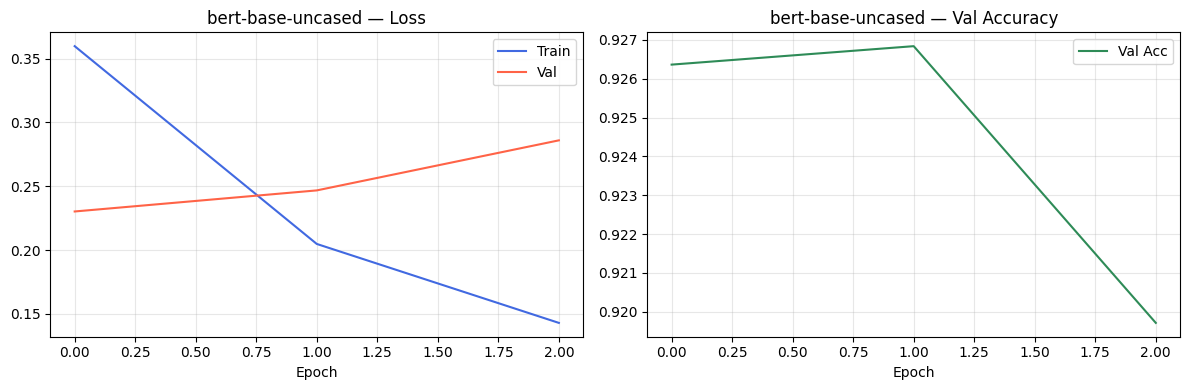

In [ ]:
bert_results, bert_history = fine_tune_transformer(
    'bert-base-uncased',
    X_train, y_train, X_val, y_val, X_test, y_test,
    epochs=3, batch_size=16, lr=2e-5
)

## 6. Fine-Tune DistilBERT


Fine-tuning: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\Abirami Muthiah\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abirami Muthiah\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3 | Train Loss 0.3751 | Val Loss 0.2287 | Val Acc 0.9259
  Epoch 2/3 | Train Loss 0.2101 | Val Loss 0.2304 | Val Acc 0.9278
  Epoch 3/3 | Train Loss 0.1581 | Val Loss 0.2453 | Val Acc 0.9183


C:\Users\Abirami Muthiah\AppData\Local\Temp\ipykernel_2660\3980990768.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_{short_nam


Test Results — distilbert-base-uncased
  Accuracy : 0.9084
  Precision: 0.9024
  Recall   : 0.9084
  F1-Score : 0.8929
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.95      1435
     Neutral       0.71      0.06      0.10        89
    Positive       0.84      0.92      0.88       582

    accuracy                           0.91      2106
   macro avg       0.83      0.65      0.64      2106
weighted avg       0.90      0.91      0.89      2106



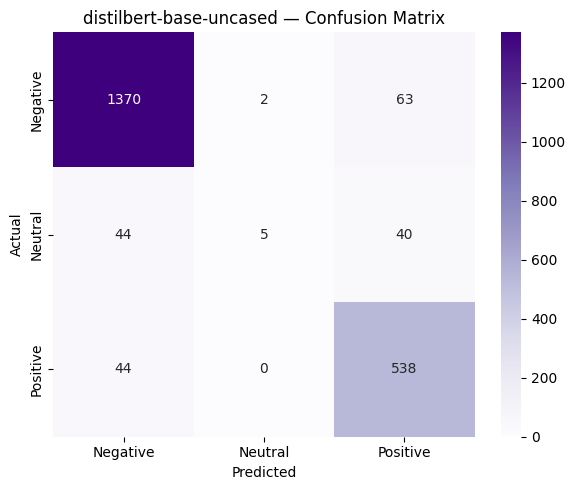

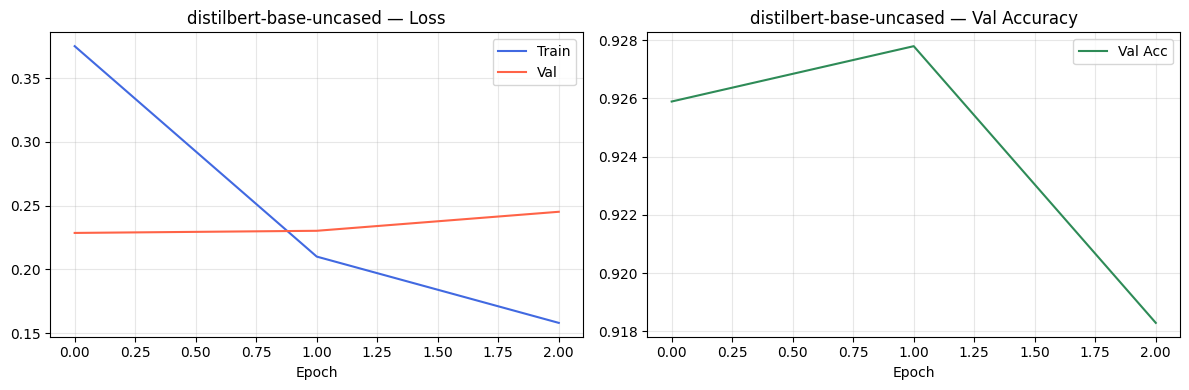

In [ ]:
# DistilBERT is 40% smaller than BERT and runs ~60% faster with comparable accuracy.
distilbert_results, distilbert_history = fine_tune_transformer(
    'distilbert-base-uncased',
    X_train, y_train, X_val, y_val, X_test, y_test,
    epochs=3, batch_size=32, lr=2e-5
)

## 7. Fine-Tune RoBERTa


Fine-tuning: roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

C:\Users\Abirami Muthiah\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abirami Muthiah\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3 | Train Loss 0.3645 | Val Loss 0.2851 | Val Acc 0.9159
  Epoch 2/3 | Train Loss 0.2181 | Val Loss 0.2325 | Val Acc 0.9292
  Epoch 3/3 | Train Loss 0.1778 | Val Loss 0.2724 | Val Acc 0.9273


C:\Users\Abirami Muthiah\AppData\Local\Temp\ipykernel_2660\3980990768.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_{short_nam


Test Results — roberta-base
  Accuracy : 0.9155
  Precision: 0.9083
  Recall   : 0.9155
  F1-Score : 0.9113
              precision    recall  f1-score   support

    Negative       0.95      0.96      0.95      1435
     Neutral       0.38      0.26      0.31        89
    Positive       0.89      0.92      0.90       582

    accuracy                           0.92      2106
   macro avg       0.74      0.71      0.72      2106
weighted avg       0.91      0.92      0.91      2106



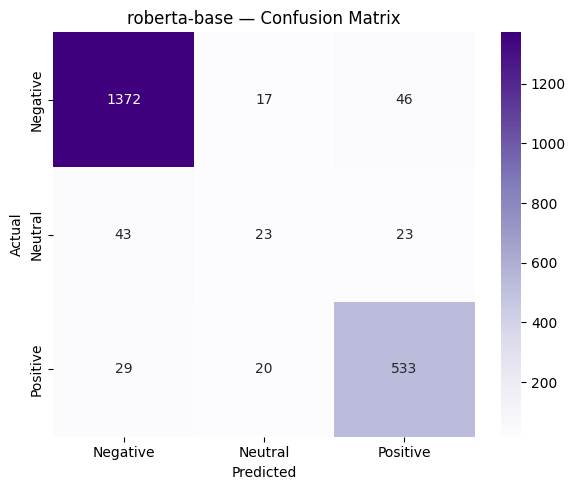

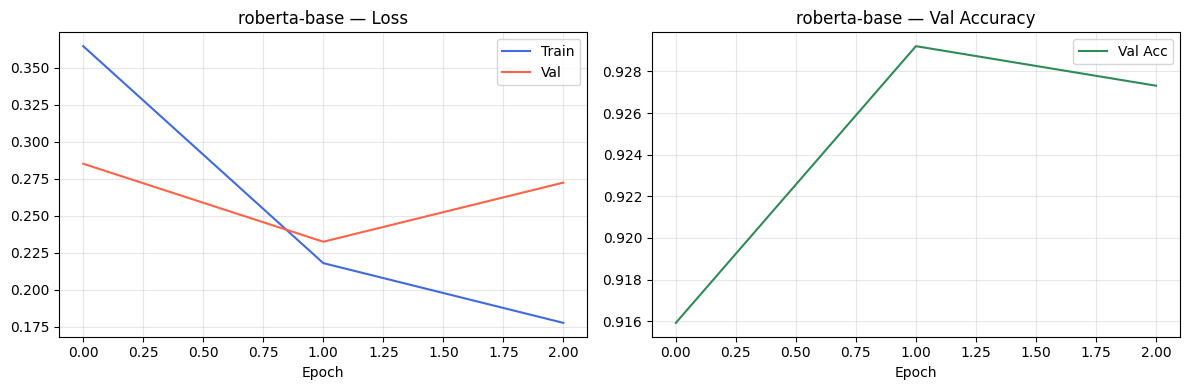

In [ ]:
# RoBERTa removes NSP, uses larger batches & more data — typically best of the three.
roberta_results, roberta_history = fine_tune_transformer(
    'roberta-base',
    X_train, y_train, X_val, y_val, X_test, y_test,
    epochs=3, batch_size=16, lr=1e-5
)

## 8. Full Model Comparison Table

                  Model  Accuracy  Precision   Recall  F1-Score
           roberta-base  0.915480   0.908290 0.915480  0.911294
      bert-base-uncased  0.912156   0.918021 0.912156  0.893824
distilbert-base-uncased  0.908357   0.902393 0.908357  0.892889
                 BiLSTM  0.870000   0.860000 0.870000  0.860000
                   LSTM  0.850000   0.840000 0.850000  0.840000
                    SVM  0.840000   0.830000 0.840000  0.830000
    Logistic Regression  0.820000   0.810000 0.820000  0.810000
            Naive Bayes  0.780000   0.770000 0.780000  0.770000


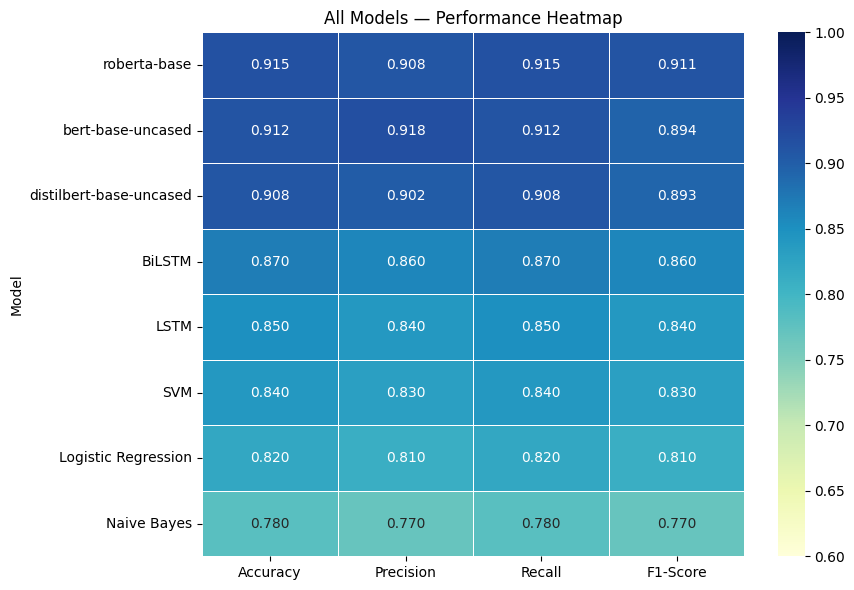

In [ ]:
# Combine ALL models (plug in Member 1 values)
all_results = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.82, 'Precision': 0.81, 'Recall': 0.82, 'F1-Score': 0.81},
    {'Model': 'Naive Bayes',         'Accuracy': 0.78, 'Precision': 0.77, 'Recall': 0.78, 'F1-Score': 0.77},
    {'Model': 'SVM',                 'Accuracy': 0.84, 'Precision': 0.83, 'Recall': 0.84, 'F1-Score': 0.83},
    {'Model': 'LSTM',                'Accuracy': 0.85, 'Precision': 0.84, 'Recall': 0.85, 'F1-Score': 0.84},
    {'Model': 'BiLSTM',              'Accuracy': 0.87, 'Precision': 0.86, 'Recall': 0.87, 'F1-Score': 0.86},
    bert_results,
    distilbert_results,
    roberta_results,
]

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))
comparison_df.to_csv('full_model_comparison.csv', index=False)

# Heatmap of all metrics
metrics_df = comparison_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]
plt.figure(figsize=(9, 6))
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0.6, vmax=1.0, linewidths=0.5)
plt.title('All Models — Performance Heatmap')
plt.tight_layout()
plt.savefig('all_models_heatmap.png', dpi=150)
plt.show()